<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/ThermodynamicsOfMethanol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thermodynamics of methanol with NeqSim

**Audience.** Process, chemical, energy, and safety engineers who know basic thermodynamics and want a reproducible methanol-property workflow in NeqSim.

**Prerequisites.** Familiarity with pressure, temperature, phases, enthalpy, and Python tables and plots. No prior NeqSim experience is required.

**Learning objectives.** By the end, you will be able to:

1. explain why methanol association matters and why CPA is the primary model here;
2. build and flash a methanol fluid with explicit SI units;
3. calculate saturation temperature, latent heat, and liquid and transport properties;
4. compare CPA with SRK and Peng-Robinson without hiding model limitations;
5. model a methanol-water liquid and a composable heating/vaporization process; and
6. verify results against NIST data, balances, and expected sensitivity trends.

This is an educational screening model, not a substitute for a design-basis review, experimental reconciliation, relief analysis, or vendor guarantees.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim",
        ]
    )

## 1. Calculation plan and units

The notebook follows the same chain used in a process model:

`fluid definition -> thermodynamic model -> flash calculation -> properties -> stream -> unit operations -> checks`

All pressures are **absolute**. Temperatures are in K, pressure in bara, density in kg/m³, heat capacity in J/(kg K), viscosity in Pa s, thermal conductivity in W/(m K), mass flow in kg/h, and duty in kW. Values called “reference” below are explicitly sourced; the other inputs define transparent educational scenarios.

The clean-runtime setup installs NeqSim only when it is absent, so a Colab session does not restart or repeat package installation.

In [2]:
from importlib.metadata import version
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim


NEQSIM_VERSION = version("neqsim")
REFERENCE_PRESSURE_BARA = 1.01325
REFERENCE_TEMPERATURE_K = 298.15
NIST_BOILING_TEMPERATURE_K = 337.8
NIST_LATENT_HEAT_KJ_PER_MOL = 35.21
REFERENCE_DENSITY_KG_PER_M3 = 786.6
NIST_CP_J_PER_MOL_K = 80.35
METHANOL_MOLAR_MASS_KG_PER_MOL = 0.032042

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.5f}")

print(f"NeqSim version [-]: {NEQSIM_VERSION}")
print("Reference basis: 298.15 K and 1.01325 bara")

NeqSim version [-]: 3.16.0
Reference basis: 298.15 K and 1.01325 bara


## 2. Why methanol needs an association model

Methanol has a polar hydroxyl group and forms hydrogen-bonded molecular networks. A conventional cubic equation of state represents repulsion and dispersion, but it does not explicitly represent association. The Cubic-Plus-Association (CPA) framework adds an association contribution to the cubic reference model:

$$
P = P_{\mathrm{SRK}} + P_{\mathrm{assoc}}
$$

Here $P$ is total pressure in Pa, $P_{\mathrm{SRK}}$ is the cubic reference contribution, and $P_{\mathrm{assoc}}$ represents the effect of hydrogen-bonded sites. NeqSim's `SystemSrkCPAstatoil` combines SRK with the association term and component parameters stored in its database.

CPA is therefore the primary model. SRK and Peng-Robinson (PR) are retained as a model-risk comparison. Agreement in boiling point alone is not evidence that a model predicts liquid density, heat capacity, mixtures, and enthalpy equally well.

In [3]:
MODEL_CLASSES = {
    "CPA": jneqsim.thermo.system.SystemSrkCPAstatoil,
    "SRK": jneqsim.thermo.system.SystemSrkEos,
    "PR": jneqsim.thermo.system.SystemPrEos,
}


def create_pure_methanol(model_name, temperature_k, pressure_bara):
    model_class = MODEL_CLASSES[model_name]
    fluid = model_class(temperature_k, pressure_bara)
    fluid.addComponent("methanol", 1.0)
    fluid.setMultiPhaseCheck(True)

    if model_name == "CPA":
        fluid.setMixingRule(10)

    return fluid


def run_tp_flash(fluid):
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()
    return fluid


base_fluid = create_pure_methanol(
    "CPA",
    REFERENCE_TEMPERATURE_K,
    REFERENCE_PRESSURE_BARA,
)
methanol_component = base_fluid.getPhase(0).getComponent("methanol")

component_data = pd.Series(
    {
        "component": str(methanol_component.getComponentName()),
        "molar mass [kg/mol]": methanol_component.getMolarMass(),
        "critical temperature [K]": methanol_component.getTC(),
        "critical pressure [bara]": methanol_component.getPC(),
        "CPA alpha/acentric parameter [-]": methanol_component.getAcentricFactor(),
    },
    name="NeqSim component data",
)
component_data

component                           methanol
molar mass [kg/mol]                  0.03204
critical temperature [K]           512.64000
critical pressure [bara]            80.96000
CPA alpha/acentric parameter [-]    -0.03101
Name: NeqSim component data, dtype: object

## 3. How NeqSim represents the fluid

A NeqSim thermodynamic system contains the model, overall composition, temperature, pressure, phases, and calculation options. `addComponent("methanol", 1.0)` uses one mole as a convenient pure-component basis; intensive results do not depend on that amount.

`setMultiPhaseCheck(True)` asks flash calculations to consider phase splitting. Mixing-rule code 10 activates the established CPA mixing rule used for associating components. It has little effect for one pure component but becomes important in the methanol-water example.

The database values shown above are model inputs, not experimental validation. For this CPA class, `getAcentricFactor()` exposes the effective alpha-function parameter used by the model; it should not be read as a separately validated literature Pitzer factor. Critical data delimit the fluid region: a vapor-liquid saturation calculation is meaningful only below the critical point. Solid methanol and chemical reaction are outside this notebook.

In [4]:
run_tp_flash(base_fluid)
base_phase = base_fluid.getPhase(0)

base_state = pd.Series(
    {
        "temperature [K]": base_fluid.getTemperature("K"),
        "pressure [bara]": base_fluid.getPressure("bara"),
        "number of phases [-]": base_fluid.getNumberOfPhases(),
        "NeqSim phase label": str(base_phase.getPhaseTypeName()),
        "density [kg/m3]": base_phase.getDensity("kg/m3"),
        "heat capacity Cp [J/(kg K)]": base_phase.getCp("J/kgK"),
        "viscosity [Pa s]": base_phase.getViscosity("kg/msec"),
        "thermal conductivity [W/(m K)]": base_phase.getThermalConductivity(
            "W/mK"
        ),
    },
    name="CPA methanol at the reference state",
)
base_state

temperature [K]                    298.15000
pressure [bara]                      1.01325
number of phases [-]                       1
NeqSim phase label                   aqueous
density [kg/m3]                    792.62686
heat capacity Cp [J/(kg K)]      2,271.42689
viscosity [Pa s]                     0.00051
thermal conductivity [W/(m K)]       0.19793
Name: CPA methanol at the reference state, dtype: object

## 4. The TP-flash solver and phase labels

A TP flash holds total composition, temperature, and pressure fixed while NeqSim minimizes the appropriate thermodynamic potential and solves phase equilibrium. At 298.15 K and 1.01325 bara, pure methanol is a single liquid.

NeqSim labels the associating liquid phase `aqueous`. That internal phase label does **not** imply that water was added: the component inventory remains pure methanol. Engineering code should inspect both phase type and composition instead of assuming phase index zero is always gas or oil.

`initProperties()` initializes density and transport-property models after equilibrium is solved. The thermodynamic model controls phase equilibrium and caloric properties; viscosity and thermal conductivity also use physical-property correlations, so their uncertainty is not identical to CPA phase-equilibrium uncertainty.

In [5]:
model_rows = []

for model_name in MODEL_CLASSES:
    comparison_fluid = create_pure_methanol(
        model_name,
        REFERENCE_TEMPERATURE_K,
        REFERENCE_PRESSURE_BARA,
    )
    run_tp_flash(comparison_fluid)
    comparison_phase = comparison_fluid.getPhase(0)

    model_rows.append(
        {
            "model": model_name,
            "phase label": str(comparison_phase.getPhaseTypeName()),
            "density [kg/m3]": comparison_phase.getDensity("kg/m3"),
            "Cp [J/(kg K)]": comparison_phase.getCp("J/kgK"),
            "viscosity [mPa s]": 1000.0
            * comparison_phase.getViscosity("kg/msec"),
            "thermal conductivity [W/(m K)]": (
                comparison_phase.getThermalConductivity("W/mK")
            ),
        }
    )

model_comparison = pd.DataFrame(model_rows).set_index("model")
model_comparison

,phase label,density [kg/m3],Cp [J/(kg K)],viscosity [mPa s],thermal conductivity [W/(m K)]
model,,,,,
CPA,aqueous,792.62686,"2,271.42689",0.50671,0.19793
SRK,aqueous,960.33170,"3,718.16243",0.50659,0.19793
PR,aqueous,"1,003.29644","3,498.26170",0.50659,0.19793


## 5. Model selection is property-specific

The model table is deliberately broad. CPA gives a much more realistic ambient liquid density than unassociated SRK or PR because association changes the residual Helmholtz energy and liquid structure. Transport values are nearly identical here because NeqSim applies a shared pure-component correlation after the flash.

The NIST liquid heat-capacity data contain multiple experimental values near 298.15 K; this notebook uses 80.35 J/(mol K) from Okano, Ogawa, et al. Converting a molar heat capacity to mass basis requires the molar mass:

$$
C_{p,m} = \frac{C_{p,n}}{M}
$$

Here $C_{p,m}$ is in J/(kg K), $C_{p,n}$ is in J/(mol K), and $M$ is in kg/mol. A single reference is used for a transparent check, not for parameter fitting.

In [6]:
reference_cp_j_per_kg_k = (
    NIST_CP_J_PER_MOL_K / METHANOL_MOLAR_MASS_KG_PER_MOL
)

model_deviations = model_comparison[["density [kg/m3]", "Cp [J/(kg K)]"]].copy()
model_deviations["density deviation [%]"] = (
    100.0
    * (model_deviations["density [kg/m3]"] - REFERENCE_DENSITY_KG_PER_M3)
    / REFERENCE_DENSITY_KG_PER_M3
)
model_deviations["Cp deviation [%]"] = (
    100.0
    * (model_deviations["Cp [J/(kg K)]"] - reference_cp_j_per_kg_k)
    / reference_cp_j_per_kg_k
)

model_deviations

,density [kg/m3],Cp [J/(kg K)],density deviation [%],Cp deviation [%]
model,,,,
CPA,792.62686,"2,271.42689",0.76619,-9.41996
SRK,960.33170,"3,718.16243",22.08641,48.27301
PR,"1,003.29644","3,498.26170",27.54849,39.50380


## 6. Vapor-liquid equilibrium and the normal boiling point

At equilibrium, each component has equal fugacity in coexisting liquid and vapor phases:

$$
f_i^{\mathrm{L}}(T,P,\mathbf{x}) = f_i^{\mathrm{V}}(T,P,\mathbf{y})
$$

For pure methanol, both compositions are one, so the saturation solver changes temperature until liquid and vapor fugacity are equal at the specified pressure. `bubblePointTemperatureFlash()` uses the current pressure and returns the temperature at which an infinitesimal vapor phase appears.

The normal boiling point is the saturation temperature at 1.01325 bara. NIST reports an average of 337.8 ± 0.3 K and individual values around 337.7 K. The comparison below tests a physical observable independently of NeqSim's component database display.

In [7]:
boiling_rows = []

for model_name in MODEL_CLASSES:
    saturation_fluid = create_pure_methanol(
        model_name,
        300.0,
        REFERENCE_PRESSURE_BARA,
    )
    saturation_operations = (
        jneqsim.thermodynamicoperations.ThermodynamicOperations(saturation_fluid)
    )
    saturation_operations.bubblePointTemperatureFlash()
    boiling_temperature_k = saturation_fluid.getTemperature("K")

    boiling_rows.append(
        {
            "model": model_name,
            "boiling temperature [K]": boiling_temperature_k,
            "NIST reference [K]": NIST_BOILING_TEMPERATURE_K,
            "deviation [K]": boiling_temperature_k
            - NIST_BOILING_TEMPERATURE_K,
        }
    )

boiling_table = pd.DataFrame(boiling_rows).set_index("model")
boiling_table

,boiling temperature [K],NIST reference [K],deviation [K]
model,,,
CPA,337.75754,337.80000,-0.04246
SRK,338.14838,337.80000,0.34838
PR,337.36859,337.80000,-0.43141


## 7. Interpreting the boiling-point benchmark

All three equations of state reproduce the pure-component normal boiling point closely because vapor-pressure behavior is strongly constrained by pure-component parameters. CPA's result should therefore be judged together with liquid density, heat capacity, mixture behavior, and enthalpy—not in isolation.

The acceptance band below is ±1 K. This is intentionally wider than the NIST experimental spread because it is a screening tolerance for a general process simulator, not a claim of reference-quality property accuracy.

Near the critical point, liquid and vapor become indistinguishable and saturation calculations become more sensitive. The next pressure sweep stops well below the NeqSim critical pressure.

In [8]:
cpa_boiling_temperature_k = boiling_table.loc[
    "CPA",
    "boiling temperature [K]",
]
cpa_boiling_error_k = cpa_boiling_temperature_k - NIST_BOILING_TEMPERATURE_K

assert abs(cpa_boiling_error_k) < 1.0
assert boiling_table["boiling temperature [K]"].between(330.0, 345.0).all()

print(f"CPA normal boiling temperature [K]: {cpa_boiling_temperature_k:.6f}")
print(f"CPA minus NIST [K]: {cpa_boiling_error_k:+.6f}")

CPA normal boiling temperature [K]: 337.757539
CPA minus NIST [K]: -0.042461


## 8. Saturation pressure sensitivity

Increasing pressure raises the boiling temperature because a higher liquid chemical potential is required to match the compressed vapor. The sweep uses the same CPA fluid definition at each independent pressure, avoiding hidden state from a previous flash.

This is a pure-component saturation curve, not a phase envelope for synthesis gas or crude methanol. Impurities such as water, dimethyl ether, dissolved gases, and higher alcohols turn boiling into a bubble/dew range and require the measured composition.

In [9]:
saturation_pressures_bara = np.array(
    [
        0.2,
        0.5,
        1.01325,
        2.0,
        5.0,
        10.0,
        20.0,
        40.0,
    ]
)
saturation_temperatures_k = []

for pressure_bara in saturation_pressures_bara:
    saturation_fluid = create_pure_methanol(
        "CPA",
        300.0,
        float(pressure_bara),
    )
    saturation_operations = (
        jneqsim.thermodynamicoperations.ThermodynamicOperations(saturation_fluid)
    )
    saturation_operations.bubblePointTemperatureFlash()
    saturation_temperatures_k.append(saturation_fluid.getTemperature("K"))

saturation_table = pd.DataFrame(
    {
        "pressure [bara]": saturation_pressures_bara,
        "saturation temperature [K]": saturation_temperatures_k,
    }
)
saturation_table

,pressure [bara],saturation temperature [K]
0,0.20000,301.56834
1,0.50000,320.89972
2,1.01325,337.75754
3,2.00000,355.95936
4,5.00000,384.32227
5,10.00000,409.50838
6,20.00000,438.87014
7,40.00000,473.61206


## 9. Reading the saturation curve

A semilogarithmic pressure axis makes the low-pressure region readable while retaining the high-pressure trend. The curve must be smooth and strictly increasing over this range. Non-monotonic behavior would indicate a failed flash, accidental unit mismatch, or inappropriate model state.

The Clausius-Clapeyron limiting form relates the curve slope to vaporization enthalpy:

$$
\frac{d\ln P_{\mathrm{sat}}}{d(1/T)} = -\frac{\Delta h_{\mathrm{vap}}}{R}
$$

$P_{\mathrm{sat}}$ is saturation pressure, $T$ is absolute temperature, $\Delta h_{\mathrm{vap}}$ is molar latent heat, and $R$ is the gas constant. The equation assumes approximately ideal vapor and weak latent-heat variation, so it is interpretive rather than the solver used by NeqSim.

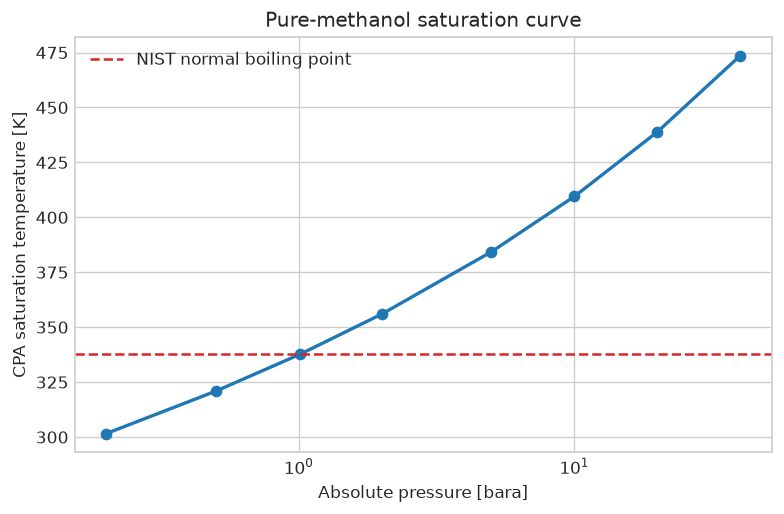

In [10]:
temperature_increments = np.diff(
    saturation_table["saturation temperature [K]"].to_numpy()
)
assert np.all(temperature_increments > 0.0)

figure, axis = plt.subplots(figsize=(7.5, 4.5))
axis.semilogx(
    saturation_table["pressure [bara]"],
    saturation_table["saturation temperature [K]"],
    marker="o",
    linewidth=2.0,
)
axis.axhline(
    NIST_BOILING_TEMPERATURE_K,
    color="tab:red",
    linestyle="--",
    label="NIST normal boiling point",
)
axis.set_xlabel("Absolute pressure [bara]")
axis.set_ylabel("CPA saturation temperature [K]")
axis.set_title("Pure-methanol saturation curve")
axis.legend()
plt.show()

## 10. Latent heat from the two saturation phases

After a bubble-point flash, NeqSim retains a nearly zero vapor fraction and a liquid phase. Each phase has a molar enthalpy. Their difference is the predicted latent heat:

$$
\Delta h_{\mathrm{vap}} = h^{\mathrm{V}} - h^{\mathrm{L}}
$$

The phase enthalpies are divided by phase moles because the vapor phase is deliberately tiny. NIST reports 35.21 kJ/mol at 337.7 K. The calculation tests both the equilibrium state and the residual/caloric model.

In [11]:
def saturation_latent_heat(model_name, pressure_bara):
    fluid = create_pure_methanol(model_name, 300.0, pressure_bara)
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.bubblePointTemperatureFlash()
    fluid.init(3)

    phase_enthalpy = {}
    for phase_index in range(fluid.getNumberOfPhases()):
        phase = fluid.getPhase(phase_index)
        molar_enthalpy_kj_per_mol = (
            phase.getEnthalpy()
            / phase.getNumberOfMolesInPhase()
            / 1000.0
        )
        phase_enthalpy[phase.getPhaseTypeName()] = molar_enthalpy_kj_per_mol

    latent_heat_kj_per_mol = (
        phase_enthalpy["gas"] - phase_enthalpy["aqueous"]
    )
    return fluid.getTemperature("K"), latent_heat_kj_per_mol


latent_rows = []
for model_name in MODEL_CLASSES:
    saturation_temperature_k, latent_heat_kj_per_mol = saturation_latent_heat(
        model_name,
        REFERENCE_PRESSURE_BARA,
    )
    latent_rows.append(
        {
            "model": model_name,
            "saturation temperature [K]": saturation_temperature_k,
            "latent heat [kJ/mol]": latent_heat_kj_per_mol,
            "deviation from NIST [%]": (
                100.0
                * (latent_heat_kj_per_mol - NIST_LATENT_HEAT_KJ_PER_MOL)
                / NIST_LATENT_HEAT_KJ_PER_MOL
            ),
        }
    )

latent_heat_table = pd.DataFrame(latent_rows).set_index("model")
latent_heat_table

,saturation temperature [K],latent heat [kJ/mol],deviation from NIST [%]
model,,,
CPA,337.75754,33.41620,-5.09458
SRK,338.14838,38.36247,8.95335
PR,337.36859,37.57189,6.70801


## 11. Independent ambient-property checks

The density reference is 786.6 kg/m³ at 25 °C from the experimental compilation surfaced by PubChem. The NIST heat-capacity datum 80.35 J/(mol K) converts to about 2507.6 J/(kg K) using 0.032042 kg/mol.

CPA's density error is small enough for this educational workflow, while its heat-capacity deviation is larger. That difference is important: an equation of state can provide useful phase equilibrium and density while caloric properties still need separate validation for high-accuracy heat-exchanger design.

Acceptance limits of 3% for density, 15% for heat capacity, and 15% for latent heat are declared before the assertions. They are screening limits, not universal NeqSim specifications.

In [12]:
cpa_density_kg_per_m3 = model_comparison.loc["CPA", "density [kg/m3]"]
cpa_cp_j_per_kg_k = model_comparison.loc["CPA", "Cp [J/(kg K)]"]
cpa_latent_heat_kj_per_mol = latent_heat_table.loc[
    "CPA",
    "latent heat [kJ/mol]",
]

density_deviation_percent = (
    100.0
    * (cpa_density_kg_per_m3 - REFERENCE_DENSITY_KG_PER_M3)
    / REFERENCE_DENSITY_KG_PER_M3
)
cp_deviation_percent = (
    100.0
    * (cpa_cp_j_per_kg_k - reference_cp_j_per_kg_k)
    / reference_cp_j_per_kg_k
)
latent_deviation_percent = (
    100.0
    * (cpa_latent_heat_kj_per_mol - NIST_LATENT_HEAT_KJ_PER_MOL)
    / NIST_LATENT_HEAT_KJ_PER_MOL
)

benchmark_table = pd.DataFrame(
    {
        "quantity": ["density", "Cp", "latent heat"],
        "CPA value": [
            cpa_density_kg_per_m3,
            cpa_cp_j_per_kg_k,
            cpa_latent_heat_kj_per_mol,
        ],
        "reference value": [
            REFERENCE_DENSITY_KG_PER_M3,
            reference_cp_j_per_kg_k,
            NIST_LATENT_HEAT_KJ_PER_MOL,
        ],
        "deviation [%]": [
            density_deviation_percent,
            cp_deviation_percent,
            latent_deviation_percent,
        ],
    }
).set_index("quantity")

assert abs(density_deviation_percent) < 3.0
assert abs(cp_deviation_percent) < 15.0
assert abs(latent_deviation_percent) < 15.0

benchmark_table

,CPA value,reference value,deviation [%]
quantity,,,
density,792.62686,786.60000,0.76619
Cp,"2,271.42689","2,507.64621",-9.41996
latent heat,33.41620,35.21000,-5.09458


## 12. Temperature sensitivity of liquid properties

The sweep remains below the normal boiling point at 1.01325 bara. Density and viscosity should decrease as the liquid warms. Heat capacity generally increases toward saturation, while the thermal-conductivity correlation should remain finite and positive.

These trends are valuable implementation checks because they catch unit errors and accidental phase changes. They are not a replacement for transport-property measurements when pressure drop, heat transfer, or rotating equipment performance is economically critical.

In [13]:
property_temperatures_k = np.array([280.0, 290.0, 300.0, 310.0, 320.0, 330.0])
property_rows = []

for temperature_k in property_temperatures_k:
    property_fluid = create_pure_methanol(
        "CPA",
        float(temperature_k),
        REFERENCE_PRESSURE_BARA,
    )
    run_tp_flash(property_fluid)
    property_phase = property_fluid.getPhase(0)

    property_rows.append(
        {
            "temperature [K]": temperature_k,
            "density [kg/m3]": property_phase.getDensity("kg/m3"),
            "Cp [J/(kg K)]": property_phase.getCp("J/kgK"),
            "viscosity [mPa s]": 1000.0
            * property_phase.getViscosity("kg/msec"),
            "thermal conductivity [W/(m K)]": (
                property_phase.getThermalConductivity("W/mK")
            ),
        }
    )

property_table = pd.DataFrame(property_rows)
property_table

,temperature [K],density [kg/m3],Cp [J/(kg K)],viscosity [mPa s],thermal conductivity [W/(m K)]
0,280.00000,808.95590,"2,112.03632",0.65376,0.20106
1,290.00000,800.03901,"2,198.45781",0.56415,0.19931
2,300.00000,790.92426,"2,288.28184",0.49518,0.19762
3,310.00000,781.57863,"2,381.11375",0.44041,0.19601
4,320.00000,771.96545,"2,476.64132",0.39557,0.19447
5,330.00000,762.04378,"2,574.65529",0.35775,0.19300


## 13. Property-trend interpretation

The two-panel figure separates density from transport properties because the scales differ. Every axis includes units, and no line is normalized without explanation.

The density and viscosity checks are directional limiting cases over the documented liquid range. If the pressure were reduced below saturation, the TP flash could create vapor and a single-phase liquid trend would no longer be the right interpretation.

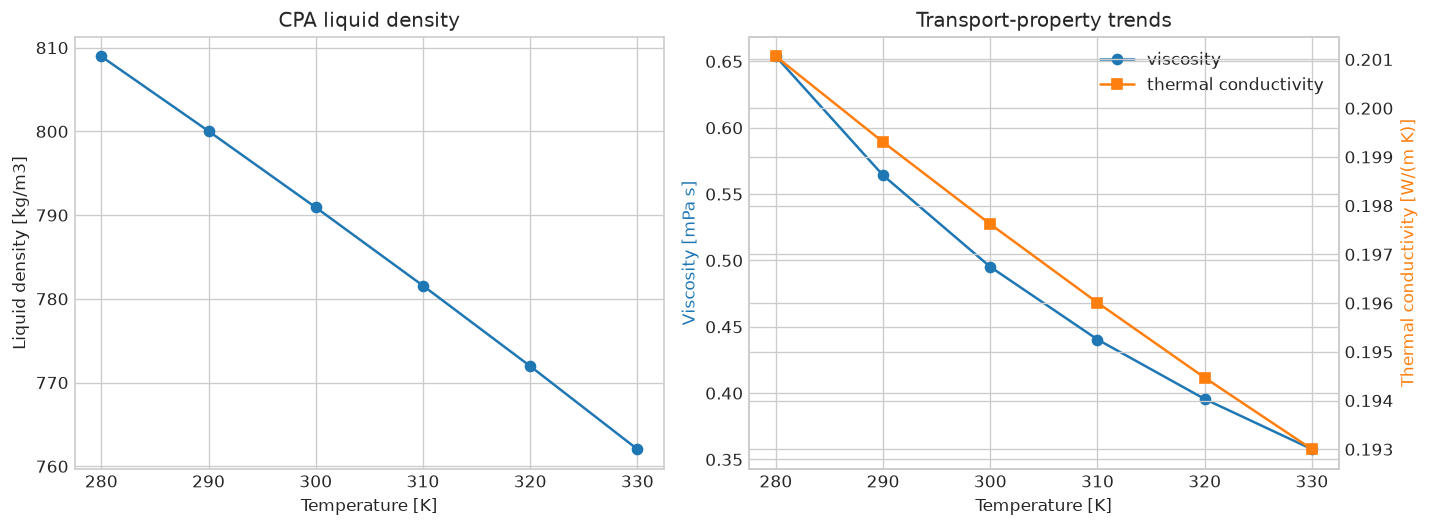

In [14]:
density_changes = np.diff(property_table["density [kg/m3]"].to_numpy())
viscosity_changes = np.diff(property_table["viscosity [mPa s]"].to_numpy())

assert np.all(density_changes < 0.0)
assert np.all(viscosity_changes < 0.0)
assert np.all(property_table["thermal conductivity [W/(m K)]"] > 0.0)

figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.5))
axes[0].plot(
    property_table["temperature [K]"],
    property_table["density [kg/m3]"],
    marker="o",
)
axes[0].set_xlabel("Temperature [K]")
axes[0].set_ylabel("Liquid density [kg/m3]")
axes[0].set_title("CPA liquid density")

viscosity_line = axes[1].plot(
    property_table["temperature [K]"],
    property_table["viscosity [mPa s]"],
    marker="o",
    color="tab:blue",
    label="viscosity",
)
conductivity_axis = axes[1].twinx()
conductivity_line = conductivity_axis.plot(
    property_table["temperature [K]"],
    property_table["thermal conductivity [W/(m K)]"],
    marker="s",
    color="tab:orange",
    label="thermal conductivity",
)
axes[1].set_xlabel("Temperature [K]")
axes[1].set_ylabel("Viscosity [mPa s]", color="tab:blue")
conductivity_axis.set_ylabel(
    "Thermal conductivity [W/(m K)]",
    color="tab:orange",
)
axes[1].set_title("Transport-property trends")
legend_lines = viscosity_line + conductivity_line
legend_labels = [line.get_label() for line in legend_lines]
axes[1].legend(legend_lines, legend_labels, loc="upper right")
plt.tight_layout()
plt.show()

## 14. Methanol-water mixtures

Real methanol systems often contain water. Both components associate, so the CPA association and cross-interaction treatment are relevant. The mixture basis below is mole fraction, and the fractions are verified to sum to one.

At 298.15 K and 1.01325 bara the selected compositions should remain one associating liquid phase. The density trend is a model prediction, not a claim of ideal-volume mixing. Detailed distillation or purification work should validate vapor-liquid equilibrium against measured binary data and assess the selected binary parameters.

In [15]:
methanol_mole_fractions = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
mixture_rows = []

for methanol_mole_fraction in methanol_mole_fractions:
    water_mole_fraction = 1.0 - methanol_mole_fraction
    mixture = jneqsim.thermo.system.SystemSrkCPAstatoil(
        REFERENCE_TEMPERATURE_K,
        REFERENCE_PRESSURE_BARA,
    )
    mixture.addComponent("methanol", float(methanol_mole_fraction))
    mixture.addComponent("water", float(water_mole_fraction))
    mixture.setMixingRule(10)
    mixture.setMultiPhaseCheck(True)
    run_tp_flash(mixture)
    liquid_phase = mixture.getPhase(0)

    mixture_rows.append(
        {
            "methanol mole fraction [-]": methanol_mole_fraction,
            "water mole fraction [-]": water_mole_fraction,
            "phase count [-]": mixture.getNumberOfPhases(),
            "phase label": liquid_phase.getPhaseTypeName(),
            "density [kg/m3]": liquid_phase.getDensity("kg/m3"),
        }
    )

mixture_table = pd.DataFrame(mixture_rows)
assert np.allclose(
    mixture_table["methanol mole fraction [-]"]
    + mixture_table["water mole fraction [-]"],
    1.0,
)
assert (mixture_table["phase count [-]"] == 1).all()

mixture_table

,methanol mole fraction [-],water mole fraction [-],phase count [-],phase label,density [kg/m3]
0,0.00000,1.00000,1,"(a, q, u, e, o, u, s)",994.99704
1,0.25000,0.75000,1,"(a, q, u, e, o, u, s)",924.49509
2,0.50000,0.50000,1,"(a, q, u, e, o, u, s)",872.29827
3,0.75000,0.25000,1,"(a, q, u, e, o, u, s)",829.78111
4,1.00000,0.00000,1,"(a, q, u, e, o, u, s)",792.62686


## 15. From a fluid to streams and unit operations

NeqSim separates thermodynamic state from process topology:

- a thermodynamic system defines CPA, composition, $T$, and $P$;
- a `Stream` attaches flow rate and provides a named connection;
- each `Heater` clones its inlet state and solves an outlet state at a specified temperature;
- a `ProcessSystem` owns units and executes them in flowsheet order.

The example heats 1000 kg/h of pure methanol at 2 bara from 298.15 K to 330 K, then to 370 K. The last temperature exceeds the CPA saturation temperature at 2 bara, so the product is vapor. Named outlet streams remain available for downstream reactors, columns, compressors, condensers, or a larger `ProcessModel`.

In [16]:
def run_methanol_heating_train(flow_rate_kg_per_h):
    process_fluid = create_pure_methanol("CPA", 298.15, 2.0)
    feed_stream = jneqsim.process.equipment.stream.Stream(
        "liquid methanol feed",
        process_fluid,
    )
    feed_stream.setFlowRate(flow_rate_kg_per_h, "kg/hr")

    preheater_unit = jneqsim.process.equipment.heatexchanger.Heater(
        "methanol preheater",
        feed_stream,
    )
    preheater_unit.setOutTemperature(330.0, "K")

    vaporizer_unit = jneqsim.process.equipment.heatexchanger.Heater(
        "methanol vaporizer",
        preheater_unit.getOutletStream(),
    )
    vaporizer_unit.setOutTemperature(370.0, "K")

    process_system = jneqsim.process.processmodel.ProcessSystem()
    process_system.add(feed_stream)
    process_system.add(preheater_unit)
    process_system.add(vaporizer_unit)
    process_system.run()

    return {
        "process": process_system,
        "feed": feed_stream,
        "preheater": preheater_unit,
        "vaporizer": vaporizer_unit,
    }


base_process = run_methanol_heating_train(1000.0)
print("Process calculation completed for 1000 kg/h of methanol.")

Process calculation completed for 1000 kg/h of methanol.


## 16. Process results and energy balance

For each steady heater with negligible kinetic and potential energy changes and no shaft work:

$$
\dot Q = \dot m\left(h_{\mathrm{out}} - h_{\mathrm{in}}\right)
$$

$\dot Q$ is duty in kW, $\dot m$ is mass flow in kg/s, and $h$ is specific enthalpy in kJ/kg. The units close because kg/s multiplied by kJ/kg equals kJ/s, or kW.

Positive duty means heat enters the methanol. The second unit includes sensible heating and vaporization. Actual exchanger design would also require utility temperatures, temperature approaches, pressure drop, UA/area, fouling, materials, and safeguards.

In [17]:
feed_stream = base_process["feed"]
preheater_unit = base_process["preheater"]
vaporizer_unit = base_process["vaporizer"]
preheated_stream = preheater_unit.getOutletStream()
vapor_stream = vaporizer_unit.getOutletStream()

named_streams = {
    "feed": feed_stream,
    "preheated liquid": preheated_stream,
    "methanol vapor": vapor_stream,
}
stream_rows = []

for stream_name, stream in named_streams.items():
    stream.run()
    system = stream.getThermoSystem()
    phase_labels = [
        str(system.getPhase(phase_index).getPhaseTypeName())
        for phase_index in range(system.getNumberOfPhases())
    ]
    stream_rows.append(
        {
            "stream": stream_name,
            "temperature [K]": system.getTemperature("K"),
            "pressure [bara]": system.getPressure("bara"),
            "mass flow [kg/h]": stream.getFlowRate("kg/hr"),
            "specific enthalpy [kJ/kg]": system.getEnthalpy("kJ/kg"),
            "phase labels": ", ".join(phase_labels),
        }
    )

stream_table = pd.DataFrame(stream_rows).set_index("stream")
mass_flow_kg_per_s = feed_stream.getFlowRate("kg/hr") / 3600.0
preheater_balance_kw = mass_flow_kg_per_s * (
    stream_table.loc["preheated liquid", "specific enthalpy [kJ/kg]"]
    - stream_table.loc["feed", "specific enthalpy [kJ/kg]"]
)
vaporizer_balance_kw = mass_flow_kg_per_s * (
    stream_table.loc["methanol vapor", "specific enthalpy [kJ/kg]"]
    - stream_table.loc["preheated liquid", "specific enthalpy [kJ/kg]"]
)

unit_table = pd.DataFrame(
    {
        "reported duty [kW]": [
            preheater_unit.getDuty("kW"),
            vaporizer_unit.getDuty("kW"),
        ],
        "enthalpy-balance duty [kW]": [
            preheater_balance_kw,
            vaporizer_balance_kw,
        ],
    },
    index=["preheater", "vaporizer"],
)

print("Stream results:")
print(stream_table.to_string())
print("\nUnit energy balances:")
unit_table

Stream results:
                  temperature [K]  pressure [bara]  mass flow [kg/h]  specific enthalpy [kJ/kg] phase labels
stream                                                                                                      
feed                    298.15000          2.00000       1,000.00000               -1,139.52013      aqueous
preheated liquid        330.00000          2.00000       1,000.00000               -1,062.42528      aqueous
methanol vapor          370.00000          2.00000       1,000.00000                   60.05872          gas

Unit energy balances:


,reported duty [kW],enthalpy-balance duty [kW]
preheater,21.41524,21.41524
vaporizer,311.80111,311.80111


## 17. Throughput sensitivity

With fixed inlet and outlet thermodynamic states and negligible pressure drop, heater duty should scale linearly with mass flow. Rebuilding and rerunning the process at each rate verifies that the process objects are composable and that no hidden state remains from the base case.

This scaling is a limiting case. In a real exchanger, increasing flow changes film coefficients, pressure drop, temperature approach, utility outlet temperature, and possibly phase distribution. The straight line is therefore a thermodynamic duty screen, not an equipment rating curve.

,mass flow [kg/h],preheater duty [kW],vaporizer duty [kW],total duty [kW]
0,250.00000,5.35381,77.95028,83.30409
1,500.00000,10.70762,155.90056,166.60817
2,"1,000.00000",21.41524,311.80111,333.21635
3,"1,500.00000",32.12286,467.70167,499.82452
4,"2,000.00000",42.83047,623.60222,666.43270


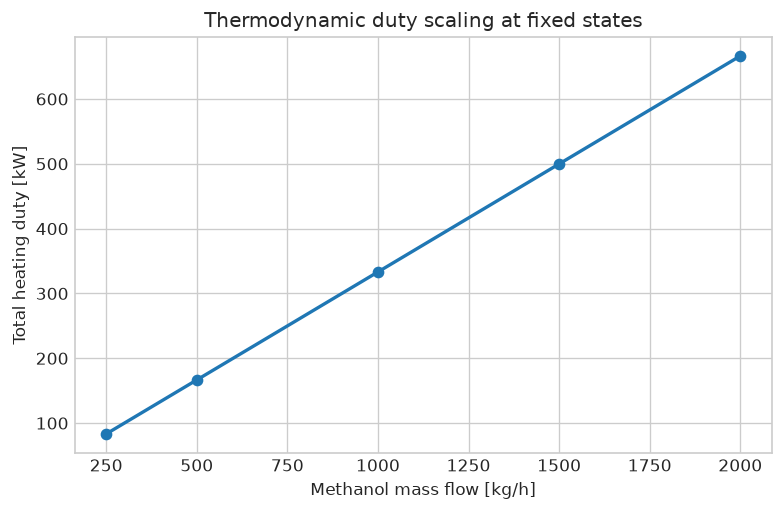

In [18]:
flow_rates_kg_per_h = np.array([250.0, 500.0, 1000.0, 1500.0, 2000.0])
throughput_rows = []

for flow_rate_kg_per_h in flow_rates_kg_per_h:
    scenario = run_methanol_heating_train(float(flow_rate_kg_per_h))
    preheater_duty_kw = scenario["preheater"].getDuty("kW")
    vaporizer_duty_kw = scenario["vaporizer"].getDuty("kW")

    throughput_rows.append(
        {
            "mass flow [kg/h]": flow_rate_kg_per_h,
            "preheater duty [kW]": preheater_duty_kw,
            "vaporizer duty [kW]": vaporizer_duty_kw,
            "total duty [kW]": preheater_duty_kw + vaporizer_duty_kw,
        }
    )

throughput_table = pd.DataFrame(throughput_rows)
specific_duty = (
    throughput_table["total duty [kW]"]
    / throughput_table["mass flow [kg/h]"]
)
assert np.allclose(specific_duty, specific_duty.iloc[0], rtol=1.0e-10)

figure, axis = plt.subplots(figsize=(7.5, 4.5))
axis.plot(
    throughput_table["mass flow [kg/h]"],
    throughput_table["total duty [kW]"],
    marker="o",
    linewidth=2.0,
)
axis.set_xlabel("Methanol mass flow [kg/h]")
axis.set_ylabel("Total heating duty [kW]")
axis.set_title("Thermodynamic duty scaling at fixed states")
plt.show()

throughput_table

## 18. Verification, troubleshooting, and limitations

The final checks cover composition, phase state, benchmarks, monotonic trends, mass conservation, heater energy balances, and throughput scaling. Typical troubleshooting:

- **No JVM or import error:** rerun the setup cell in a clean Python/Java 17 Colab runtime.
- **Component not found:** use the exact database name `methanol`.
- **Unexpected phase:** confirm K versus °C and bara versus Pa, then inspect phase labels and composition.
- **Failed saturation flash:** start below the critical point and avoid carrying a previous state into a new pressure case.
- **Different results:** report the NeqSim version and rerun all cells from the top.

Important limits include pure or binary educational compositions, equilibrium phases, no solids, no reaction, no electrolytes, no pressure drop, and no exchanger geometry or control. Methanol is toxic and highly flammable; this model does not establish safe operating limits.

In [19]:
checks = {
    "pure composition closes": abs(
        base_fluid.getPhase(0).getComponent("methanol").getz() - 1.0
    )
    < 1.0e-12,
    "reference state is one liquid": (
        base_fluid.getNumberOfPhases() == 1
        and base_fluid.getPhase(0).getPhaseTypeName() == "aqueous"
    ),
    "CPA normal boiling benchmark": abs(cpa_boiling_error_k) < 1.0,
    "saturation temperature rises with pressure": np.all(
        temperature_increments > 0.0
    ),
    "CPA density benchmark": abs(density_deviation_percent) < 3.0,
    "CPA heat-capacity benchmark": abs(cp_deviation_percent) < 15.0,
    "CPA latent-heat benchmark": abs(latent_deviation_percent) < 15.0,
    "liquid density falls with temperature": np.all(density_changes < 0.0),
    "liquid viscosity falls with temperature": np.all(viscosity_changes < 0.0),
    "transport properties stay positive": np.all(
        property_table["thermal conductivity [W/(m K)]"] > 0.0
    ),
    "binary compositions close": np.allclose(
        mixture_table["methanol mole fraction [-]"]
        + mixture_table["water mole fraction [-]"],
        1.0,
    ),
    "binary cases remain single phase": (
        mixture_table["phase count [-]"] == 1
    ).all(),
    "process mass flow closes": np.allclose(
        stream_table["mass flow [kg/h]"],
        stream_table.iloc[0]["mass flow [kg/h]"],
        rtol=0.0,
        atol=1.0e-9,
    ),
    "preheater energy balance closes": np.isclose(
        preheater_unit.getDuty("kW"),
        preheater_balance_kw,
        rtol=1.0e-10,
    ),
    "vaporizer energy balance closes": np.isclose(
        vaporizer_unit.getDuty("kW"),
        vaporizer_balance_kw,
        rtol=1.0e-10,
    ),
    "final stream is vapor": (
        vapor_stream.getThermoSystem().getPhase(0).getPhaseTypeName() == "gas"
    ),
    "heating duties are positive": (
        preheater_unit.getDuty("kW") > 0.0
        and vaporizer_unit.getDuty("kW") > 0.0
    ),
    "duty scales linearly with flow": np.allclose(
        specific_duty,
        specific_duty.iloc[0],
        rtol=1.0e-10,
    ),
}

for check_name, passed in checks.items():
    assert passed, check_name

checks_passed = int(sum(checks.values()))
print(f"Engineering checks passed [-]: {checks_passed}")
for check_name in checks:
    print(f"PASS - {check_name}")

summary = {
    "neqsim_version": NEQSIM_VERSION,
    "checks_passed": checks_passed,
    "cpa_boiling_temperature_k": float(cpa_boiling_temperature_k),
    "cpa_boiling_error_k": float(cpa_boiling_error_k),
    "cpa_density_kg_per_m3": float(cpa_density_kg_per_m3),
    "cpa_density_deviation_percent": float(density_deviation_percent),
    "cpa_latent_heat_kj_per_mol": float(cpa_latent_heat_kj_per_mol),
    "cpa_latent_deviation_percent": float(latent_deviation_percent),
    "preheater_duty_kw": float(preheater_unit.getDuty("kW")),
    "vaporizer_duty_kw": float(vaporizer_unit.getDuty("kW")),
}
print(json.dumps(summary, indent=2, sort_keys=True))

Engineering checks passed [-]: 18
PASS - pure composition closes
PASS - reference state is one liquid
PASS - CPA normal boiling benchmark
PASS - saturation temperature rises with pressure
PASS - CPA density benchmark
PASS - CPA heat-capacity benchmark
PASS - CPA latent-heat benchmark
PASS - liquid density falls with temperature
PASS - liquid viscosity falls with temperature
PASS - transport properties stay positive
PASS - binary compositions close
PASS - binary cases remain single phase
PASS - process mass flow closes
PASS - preheater energy balance closes
PASS - vaporizer energy balance closes
PASS - final stream is vapor
PASS - heating duties are positive
PASS - duty scales linearly with flow
{
  "checks_passed": 18,
  "cpa_boiling_error_k": -0.04246078674907494,
  "cpa_boiling_temperature_k": 337.75753921325094,
  "cpa_density_deviation_percent": 0.766191523676345,
  "cpa_density_kg_per_m3": 792.6268625252382,
  "cpa_latent_deviation_percent": -5.094583012661676,
  "cpa_latent_heat_

## 19. Summary, exercises, and authoritative references

**Summary.** CPA is the defensible default among the models screened here because methanol associates and CPA substantially improves ambient liquid density. NeqSim represents the fluid and model in a thermodynamic system, solves equilibrium through flash operations, initializes physical properties, and passes states between named streams and unit operations. The notebook verifies boiling point, latent heat, density, heat capacity, phase behavior, process mass and energy balances, and sensitivity trends.

**Further exercises.**

1. Replace pure methanol with a measured crude-methanol analysis and plot its bubble/dew range.
2. Compare a methanol-water isobaric bubble curve with public binary VLE data before using it for separation design.
3. Add exchanger pressure drop, utility streams, and a minimum temperature approach.
4. Connect the vapor stream to the existing methanol-production example and preserve its stream interface.
5. Repeat the benchmark at 2, 5, and 10 bara and quantify model spread.

**References.**

- NIST Chemistry WebBook, SRD 69, [methanol phase-change data](https://webbook.nist.gov/cgi/cbook.cgi?ID=C67561&Mask=4&Units=SI): normal boiling point and vaporization enthalpy.
- NIST Chemistry WebBook, [methanol liquid heat capacities](https://webbook.nist.gov/cgi/cbook.cgi?ID=C67561&Mask=B): experimental $C_p$ values near 298.15 K.
- NIST Chemistry WebBook, [thermophysical fluid-property interface](https://webbook.nist.gov/chemistry/fluid/).
- PubChem, [Methanol compound summary](https://pubchem.ncbi.nlm.nih.gov/compound/methanol): identity, hazards, and compiled density data.
- CDC/NIOSH, [Pocket Guide entry for methyl alcohol](https://www.cdc.gov/niosh/npg/npgd0397.html): toxicity, flammability, exposure, and physical-property context.
- Kontogeorgis and Folas, *Thermodynamic Models for Industrial Applications*, Wiley, 2010: cubic-plus-association theory and application limits.
- NeqSim [PyPI project](https://pypi.org/project/neqsim/): current Python package and runtime requirements.